In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
import matplotlib.pyplot as plt

In [2]:
stock_symbol = 'MSFT'
df= yf.download(stock_symbol, start='2010-01-01', end='2026-01-26',multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,23.130053,23.242153,22.861011,22.883432,38409100
2010-01-05,23.137527,23.242156,22.898380,23.055321,49749600
2010-01-06,22.995537,23.227211,22.808703,23.077743,58182400
2010-01-07,22.756390,22.943224,22.562082,22.890909,50559700
2010-01-08,22.913324,23.077738,22.599443,22.629337,51197400


In [4]:
df['Previous Close'] = df['Close'].shift(1)
df['Price Change'] = df['Close'] - df['Previous Close']
df['High-Low'] = df['High'] - df['Low']
df['Open-Close'] = df['Open'] - df['Close']
df['MA_5'] = df['Close'].rolling(window=5).mean()
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

In [5]:
df.dropna(inplace=True)

In [6]:
X=df[['Previous Close', 'Price Change', 'High-Low', 'Open-Close', 'MA_5', 'MA_20', 'MA_50', 'Volume']]
y=df['Close']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train.head()

,Previous Close,Price Change,High-Low,Open-Close,MA_5,MA_20,MA_50,Volume
Date,,,,,,,,
2014-06-12,34.396141,-0.235710,0.496665,0.193615,34.564500,34.043422,33.668769,29818900
2012-05-17,23.725586,-0.142838,0.396749,0.214245,24.005983,24.683615,24.915632,48484000
2012-05-30,23.455788,-0.174566,0.285658,0.007935,23.192348,23.882734,24.558229,41585500
2024-12-13,446.267975,-2.273254,5.807168,1.161446,443.760461,427.088249,420.323210,20177800
2012-08-02,23.336769,-0.174570,0.444360,0.015869,23.403419,23.466900,23.521175,39520500


In [9]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [10]:
mean_squared_error_value = mean_squared_error(y_test, y_pred_rf)
print(f'Mean Squared Error (RandomForest): {mean_squared_error_value}')

Mean Squared Error (RandomForest): 3.530804001864964


In [11]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [12]:
mean_squared_error_xgb = mean_squared_error(y_test, y_pred_xgb)
print(f'Mean Squared Error (XGBoost): {mean_squared_error_xgb}')

Mean Squared Error (XGBoost): 3.3498403933534515


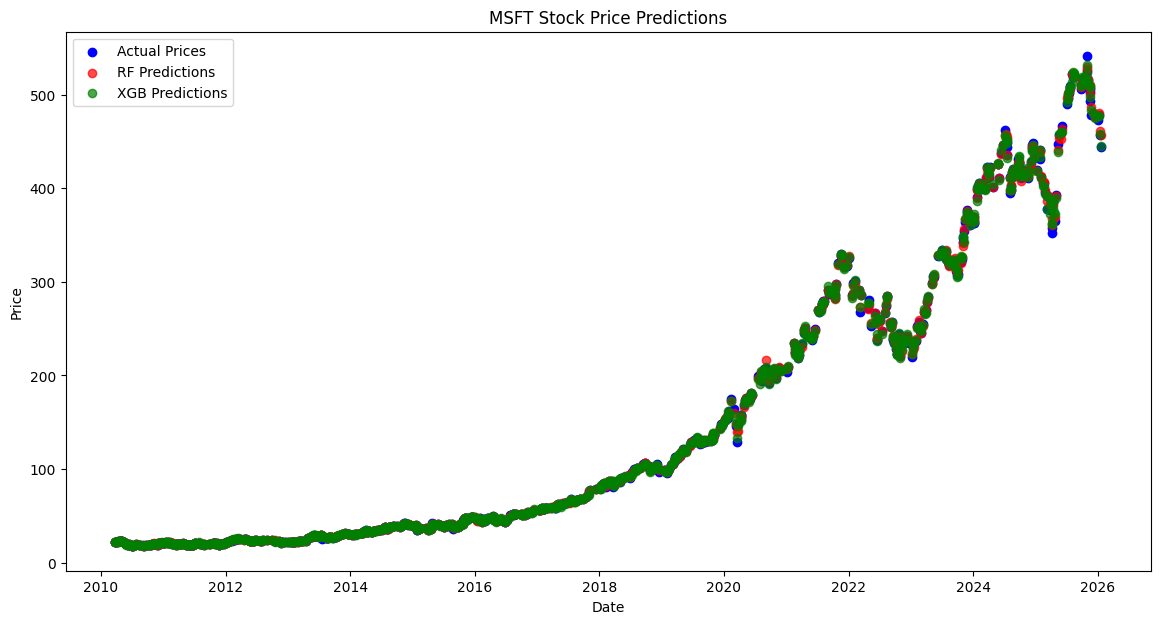

In [13]:
# Plotting the predictions
plt.figure(figsize=(14, 7))
plt.scatter(y_test.index, y_test, label='Actual Prices', color='blue')
plt.scatter(y_test.index, y_pred_rf, label='RF Predictions', color='red', alpha=0.7)
plt.scatter(y_test.index, y_pred_xgb, label='XGB Predictions', color='green', alpha=0.7)
plt.title(f'{stock_symbol} Stock Price Predictions')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [14]:
from datetime import timedelta

last_date = df.index[-1]
future_dates = [last_date + timedelta(days=1)]
future_data = pd.DataFrame(index=future_dates)

In [15]:
last_row = df.iloc[-1]
# Fill future data with last known values
for date in future_dates:
    future_data.loc[date, 'Previous Close'] = last_row['Close']
    future_data.loc[date, 'Price Change'] = 0
    future_data.loc[date, 'High-Low'] = 0
    future_data.loc[date, 'Open-Close'] = 0
    future_data.loc[date, 'MA_5'] = last_row['MA_5']
    future_data.loc[date, 'MA_20'] = last_row['MA_20']
    future_data.loc[date, 'MA_50'] = last_row['MA_50']
    future_data.loc[date, 'Volume'] = last_row['Volume']

In [16]:
rf_future_price = rf_model.predict(future_data)
xgb_future_price = xgb_model.predict(future_data)
real_stock_price = yf.download(stock_symbol, start=future_dates[0], end=future_dates[0] + timedelta(days=1),progress=False,multi_level_index=False)

print(f"Future Price Prediction (Random Forest): {rf_future_price[0]}")
print(f"Future Price Prediction (XGBoost): {xgb_future_price[0]}")
print(f"Real Stock Price: {real_stock_price['Close'].values[0]}")
print(f"Future Date: {future_dates[0].date()}")

Future Price Prediction (Random Forest): 464.2620816040039
Future Price Prediction (XGBoost): 468.19818115234375
Real Stock Price: 465.95001220703125
Future Date: 2026-01-24


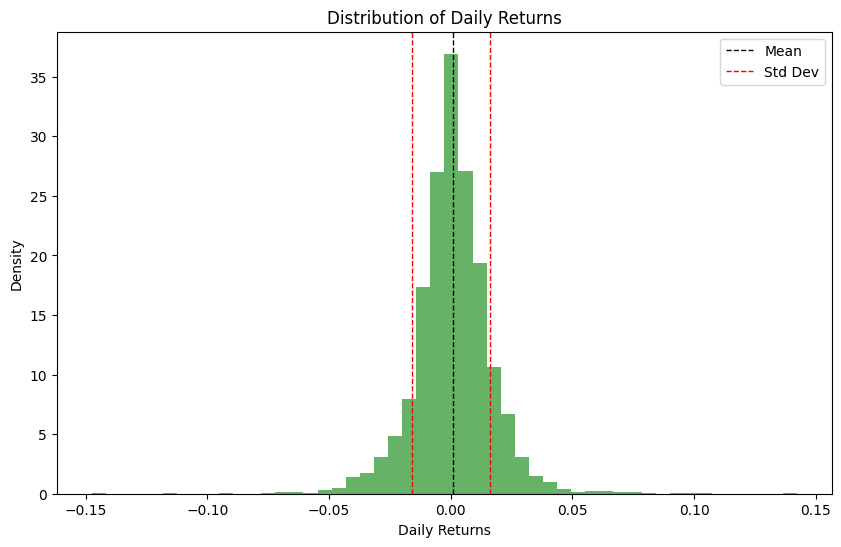

In [17]:
df['pct_change'] = df['Close'].pct_change()
#plot normal distribution of returns
plt.figure(figsize=(10, 6))
plt.hist(df['pct_change'].dropna(), bins=50, density=True, alpha=0.6, color='g')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Returns')
plt.ylabel('Density')
plt.axvline(df['pct_change'].mean(), color='k', linestyle='dashed', linewidth=1)
plt.axvline(df['pct_change'].std(), color='r', linestyle='dashed', linewidth=1)
plt.axvline(-df['pct_change'].std(), color='r', linestyle='dashed', linewidth=1)
plt.legend(['Mean', 'Std Dev'])
plt.show()